## NLP Pipeline:


*   1) Text Gathering
*   2) Text Preprocessing (Tokenization , LowerCasing , Cleaning , Lemma/Stemming)
*   3) Feature Extraction (TF-IDF , BOW ,word2vec)
*   4) Modeling & Evaluation


*   5) Deployment










## Importing Libraries

In [ ]:
!pip install transformers datasets torch scikit-learn arabert -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 7.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.naive_bayes import MultinomialNB
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import re


##Loading Data

In [ ]:
ds=load_dataset('labr')
df=pd.DataFrame(ds['train'])
df.head(10)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/3.83M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/919k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11760 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2935 [00:00<?, ? examples/s]

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,0
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,0
3,خيالية جدًا . ماحبيتها الصراحة,0
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",0
5,أحببت أسلوب الكتابة لا أكثر. بقيت أنتظر الأحد...,0
6,توقفت عن قراءته ، لعدة اسباب. لم يعجبني الكتا...,0
7,مراجعاتي دوما طوييييلة وهالمره مختصر مفيد خسا...,0
8,أسوأ ما قرأت ليوسف زيدان أيضا عرفت النهاية من...,0
9,ممله بعض الشئ و نهاية دارمية بحته,0


In [ ]:
print(df.shape)

(11760, 2)


In [ ]:
df['label'].unique()

array([0, 1, 2, 3, 4])

In [ ]:
df['label'].value_counts()

,count
label,
0,2352
1,2352
2,2352
3,2352
4,2352


In [ ]:
def convert_label(rating):

    if rating >=3:
      return 1 #positive

    elif rating<=2:
      return 0 #Negative

    #Not Classed
    else:
      return None


In [ ]:
df['Label_Edited']=df['label'].apply(convert_label)

In [ ]:
df=df.dropna(subset=['Label_Edited'])
df['Label_Edited']=df['Label_Edited'].astype(int)

In [ ]:
df['Label_Edited'].value_counts()

,count
Label_Edited,
0,7056
1,4704


In [ ]:
print(df.columns)

Index(['text', 'label', 'Label_Edited'], dtype='object')


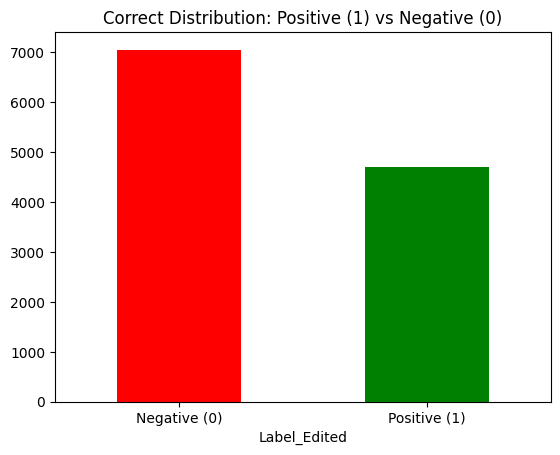

In [ ]:
df['Label_Edited'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Correct Distribution: Positive (1) vs Negative (0)')
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'], rotation=0)
plt.show()

##Making data balanced (UnderSampling)

In [ ]:
from sklearn.utils import resample
df_pos = df[df['Label_Edited'] == 1]
df_neg = df[df['Label_Edited'] == 0]

df_neg_downsampled = resample(df_neg, replace=False, n_samples=len(df_pos), random_state=42)
df_balanced = pd.concat([df_neg_downsampled, df_pos])
print(df_balanced['Label_Edited'].value_counts())

Label_Edited
0    4704
1    4704
Name: count, dtype: int64


## Cleaning

In [ ]:
def clean_text(text):

  text=re.sub(r'http\S+', '', text)

  text=re.sub(r'[أإآ]','ا',text)
  text=re.sub(r'[ة]','ه',text)
  text=re.sub(r'[ؤ]','ء',text)
  text=re.sub(r'[ئ]','ء',text)
  text=re.sub(r"ى", "ي",text)
  text = re.sub(r'(\w)\1{2,}', r'\1', text)
  text = re.sub(r'([^\w\s])\1+', r'\1', text)
  text = re.sub(r'[^\u0600-\u06FF\s\!\؟\.]', '', text)

  arabic_stopwords = [
        "انا", "انت", "او", "الي", "التي", "الذي", "ان", "بل", "ثم",
        "حيث", "حين", "ذلك", "عبر", "علي", "عن", "في", "لكن", "لم",
        "لن", "ما", "مع", "من", "هذا", "هذه", "هل", "هم", "هو", "هي", "يا",
        "انه", "انها", "انهم", "انك", "انني", "اننا", "فيها", "فيه", "عليهم", "عليه",
        "خالد", "احمد", "محمد", "محمود", "حسن", "عمر", "ساره", "فاطمه", "علي", "مصطفي",
        "مصر", "السعوديه", "الامارات", "الكويت", "قطر", "البحرين", "عمان",
        "العراق", "الاردن", "سوريا", "لبنان", "فلسطين", "اليمن", "ليبيا",
        "تونس", "الجزائر", "المغرب", "السودان", "الصومال", "جيبوتي", "موريتانيا" ]

  clean_word=[w for w in text.split() if w not in arabic_stopwords]

  return ' '.join(clean_word)

In [ ]:
#testing
sample = "المطعم ده جميييييييييل جداً !!!!!!!! http://link.com"
test_text = "ممتاااااااااااز جداااااااااا!!!!!!!!!!!! وينفع كدة.........؟؟؟؟؟؟؟؟"
print(clean_text(sample))
print(clean_text(test_text).split())
#
print(clean_text(test_text))

المطعم ده جميل جداً !
['ممتاز', 'جدا!', 'وينفع', 'كده.؟']
ممتاز جدا! وينفع كده.؟


In [ ]:
df_balanced['Cleaned_Text']=df_balanced['text'].apply(clean_text)

In [ ]:
print(df_balanced[['Cleaned_Text','text']].head())

                                           Cleaned_Text  \
1835  سقف الكفايه تنضم احببتك اكثر مما ينبغي ! يعجبن...   
5559  كتاب خفيف جدا انهيته اقل ساعتين، يتحذث القديمي...   
6792  ارهقتني الروايه ، بقدر جذبتني لاستكمالها لمعرف...   
970   مشكلات بقتش موجوده زماننا دلوقتي ، كتاب لا يسم...   
6808  كتاب خفيف ومحتواه بسيط تنتهي منه خلال يوم واحد...   

                                                   text  
1835   سقف الكفايه تنضم الى احببتك اكثر مما ينبغي ! ...  
5559   كتاب خفيف جدا أنهيته في أقل من ساعتين، يتحذث ...  
6792   أرهقتني هذه الرواية ، بقدر ما جذبتني لاستكمال...  
970    مشكلات ما بقتش موجودة فى زماننا دلوقتى ،، كتا...  
6808   كتاب خفيف ومحتواه بسيط تنتهي منه خلال يوم واح...  


## Spliting Data

In [ ]:
X=df_balanced['Cleaned_Text']
y=df_balanced['Label_Edited']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 7526 | Test: 1882


##TF-IDF + Logistic Regression

In [ ]:
#Vectorize
tfidf=TfidfVectorizer(ngram_range=(1,2),max_features=15000)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

lr_model=LogisticRegression(class_weight='balanced')
lr_model.fit(X_train_tfidf,y_train)
y_pred=lr_model.predict(X_test_tfidf)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.77      0.75       933
           1       0.76      0.73      0.75       949

    accuracy                           0.75      1882
   macro avg       0.75      0.75      0.75      1882
weighted avg       0.75      0.75      0.75      1882



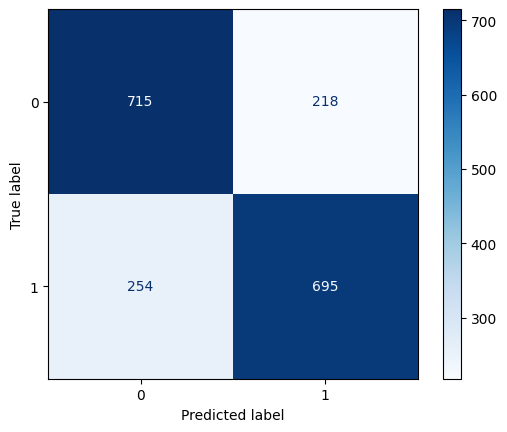

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

## LSTM Model

In [ ]:
#Tokenizer
max_words=10000
max_len=100

tokenizer=Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)
X_train_pad=pad_sequences(X_train_seq,maxlen=max_len)
X_test_pad=pad_sequences(X_test_seq,maxlen=max_len)

In [ ]:
word_dict = tokenizer.word_index
print(dict(list(word_dict.items())[:200]))

{'في': 1, 'من': 2, 'و': 3, 'ان': 4, 'علي': 5, 'لا': 6, 'ما': 7, 'عن': 8, '،': 9, 'الكتاب': 10, 'الروايه': 11, 'لم': 12, 'التي': 13, 'الي': 14, 'هذا': 15, 'كل': 16, 'كان': 17, 'او': 18, 'الذي': 19, 'كتاب': 20, 'هو': 21, 'هذه': 22, 'روايه': 23, 'مع': 24, 'انه': 25, 'الله': 26, 'اكثر': 27, 'هي': 28, 'حتي': 29, 'بين': 30, 'الكاتب': 31, 'فيها': 32, 'الا': 33, 'جدا': 34, 'كانت': 35, 'لكن': 36, 'بعد': 37, 'فيه': 38, 'اللي': 39, 'ولا': 40, 'بعض': 41, 'انها': 42, 'كما': 43, 'ذلك': 44, 'كنت': 45, 'غير': 46, 'اي': 47, 'ولكن': 48, 'قد': 49, 'انا': 50, 'راءع': 51, 'له': 52, 'لي': 53, '؟': 54, 'لو': 55, 'اني': 56, 'به': 57, 'تلك': 58, 'بها': 59, 'منها': 60, 'بس': 61, 'قرات': 62, 'الاحداث': 63, 'قبل': 64, 'مش': 65, 'الكثير': 66, 'جداً': 67, 'اسلوب': 68, 'ليس': 69, 'لها': 70, 'يكون': 71, 'الحياه': 72, 'راءعه': 73, 'شيء': 74, 'عندما': 75, 'عليه': 76, 'قصه': 77, 'اخر': 78, 'فقط': 79, 'كيف': 80, 'مره': 81, 'الكتب': 82, 'يا': 83, 'النهايه': 84, 'القصه': 85, 'القراءه': 86, 'بل': 87, 'الحب': 88, 'احمد': 89,

In [ ]:
sample_index = 1 # أول جملة في الداتا
print("الجملة الأصلية (نص):", X_train.iloc[sample_index])
print("الجملة بعد التكويد (أرقام):", X_train_seq[sample_index])

الجملة الأصلية (نص): قمه في الابداع والرومانسيه يا مالك قلوب المحبين
الجملة بعد التكويد (أرقام): [1090, 1, 880, 83, 7229, 3007, 4647]


In [ ]:
model = Sequential([

    Embedding(max_words, 128, input_length=max_len),

    LSTM(64, dropout=0.25, recurrent_dropout=0.2,return_sequences=True),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2,return_sequences=True),
    LSTM(256, dropout=0.25, recurrent_dropout=0.2,return_sequences=True),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2,return_sequences=False),
    #Classifier
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
history=model.fit(X_train_pad, y_train, epochs=5, batch_size=32,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.7503 - loss: 0.5672 - val_accuracy: 0.7483 - val_loss: 0.5603
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.7460 - loss: 0.5729 - val_accuracy: 0.7483 - val_loss: 0.5642
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.7515 - loss: 0.5609 - val_accuracy: 0.7483 - val_loss: 0.5600
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.7985 - loss: 0.4533 - val_accuracy: 0.7689 - val_loss: 0.4906
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8929 - loss: 0.2666 - val_accuracy: 0.7862 - val_loss: 0.4827


In [ ]:
model.save('LSTM_Review_Sense.h5')

In [ ]:
from tensorflow.keras.models import load_model
LSTMmodel=tf.keras.models.load_model('LSTM_Review_Sense.h5')

In [ ]:
#Evaluate Model
loss, accuracy = LSTMmodel.evaluate(X_test_pad, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 581ms/step - accuracy: 0.4952 - loss: 1.1646
Test Loss: 1.1646
Test Accuracy: 0.4952


In [ ]:
#Predicting
t1='!!!!هذا منتج تحفه جداااااااا'
t2='انه ليس الافضل مطلقا'
t3='ممل جدا'
t4='استمتعت للغايه بمقابلتك شكرا '
t5='موبايلات فاجره'
for i in [t1,t2,t3,t4,t5]:
  print(model.predict(pad_sequences(tokenizer.texts_to_sequences([i]), maxlen=max_len)))
  if model.predict(pad_sequences(tokenizer.texts_to_sequences([i]), maxlen=max_len))>0.5:
    print('✅ايجابي')
  else:
    print('❌سلبي')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
[[0.6628839]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
✅ايجابي
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
[[0.23964593]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
❌سلبي
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
[[0.06595635]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
❌سلبي
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
[[0.5401522]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
✅ايجابي
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
[[0.28832188]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
❌سلبي


##Transformers With AraBERT

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import torch

model_name = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_ara = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
train_df=pd.DataFrame({'text':X_train,'label':y_train})
test_df=pd.DataFrame({'text':X_test,'label':y_test})

In [ ]:
train_dataset=Dataset.from_pandas(train_df)
test_dataset=Dataset.from_pandas(test_df)

In [ ]:
#Tokenization (sub-word), Numericalization,Special Tokens
def tokenize(batch):
  return tokenizer(batch['text'],
                   truncation=True,
                   padding='max_length',
                   max_length=128)
train_dataset=train_dataset.map(tokenize,batched=True)
test_dataset=test_dataset.map(tokenize,batched=True)

Map:   0%|          | 0/7526 [00:00<?, ? examples/s]

Map:   0%|          | 0/1882 [00:00<?, ? examples/s]

In [ ]:
#Evaluating
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions)
    }

In [ ]:
from transformers import EarlyStoppingCallback

training_args=TrainingArguments(
    output_dir='./arabert-sentiment',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='./logs',
    learning_rate=2e-5,
    )

trainer=Trainer(
    model=model_ara,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.177527,1.324526,0.754516,0.774634
2,0.147602,1.410796,0.773645,0.775789
3,0.154240,1.369771,0.782147,0.790816


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2823, training_loss=0.15006143405764313, metrics={'train_runtime': 792.0047, 'train_samples_per_second': 28.507, 'train_steps_per_second': 3.564, 'total_flos': 1485130351979520.0, 'train_loss': 0.15006143405764313, 'epoch': 3.0})

In [ ]:
model_path = "./my_best_arabert_model_v79"

trainer.save_model(model_path)

tokenizer.save_pretrained(model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./my_best_arabert_model_v79/tokenizer_config.json',
 './my_best_arabert_model_v79/tokenizer.json')

In [ ]:
!zip -r model.zip /content/my_best_arabert_model_v79

from google.colab import files
files.download('model.zip')

  adding: content/my_best_arabert_model_v79/ (stored 0%)
  adding: content/my_best_arabert_model_v79/model.safetensors (deflated 7%)
  adding: content/my_best_arabert_model_v79/tokenizer_config.json (deflated 43%)
  adding: content/my_best_arabert_model_v79/config.json (deflated 52%)
  adding: content/my_best_arabert_model_v79/tokenizer.json (deflated 74%)
  adding: content/my_best_arabert_model_v79/training_args.bin (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         Model  Accuracy  F1 Score
0  TF-IDF + LR  0.784272  0.788762
1      AraBERT  0.819341  0.819149


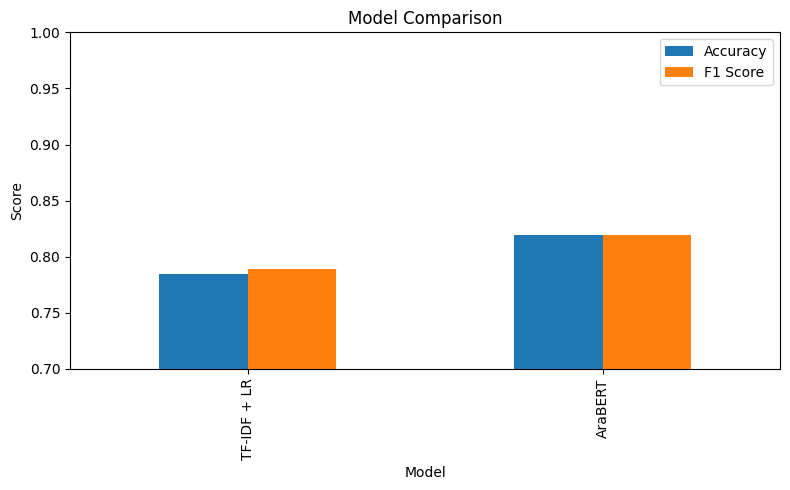

In [ ]:
# AraBERT predictions
arabert_preds = trainer.predict(test_dataset)
y_pred_arabert = np.argmax(arabert_preds.predictions, axis=-1)

results = {
    'Model': ['TF-IDF + LR', 'AraBERT'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_arabert)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_arabert)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

# Plot
results_df.plot(x='Model', kind='bar', figsize=(8,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
model = trainer.model
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=128
    ).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    label = torch.argmax(probs).item()
    labels_map = {0: '😤 سلبي', 1: '😊 ايجابي'}
    return labels_map[label], f"{probs[0][label].item():.2%}"

# جرب
text = " الكتاب ده رائع جداً"
result1, confidence1 = predict(text)
text2 = "الكتاب ده سيئ جدا"
result, confidence = predict(text2)
text3="المنتج وصل مكسور والجودة رديئة للغاية، لا أنصح به."
result3,confidence3=predict(text3)
text4="تأخير غريب في الشحن ومحدش بيرد على التليفونات، خدمة زفت."
result4,confidence4=predict(text4)
text5="كنت فاكره وحش لاني سمعت عنه كلام كتير بس التجربه خير دليل "
res5,con5=predict(text5)
text6='رحم الله العراب احمد خالد توفيق علي تعاليمه وقيمة التاركه لنا و جعل لدينا قدوة'

print(f"Result: {result1} | Confidence: {confidence1}")
print(f"Result: {result} | Confidence: {confidence}")
print(f"Result: {result3} | Confidence: {confidence3}")
print(f"Result: {result4} | Confidence: {confidence4}")
print(f"Result: {res5} | Confidence: {con5}")



Result: 😊 ايجابي | Confidence: 96.01%
Result: 😤 سلبي | Confidence: 95.87%
Result: 😤 سلبي | Confidence: 97.17%
Result: 😤 سلبي | Confidence: 95.74%
Result: 😤 سلبي | Confidence: 92.74%


In [ ]:
import torch

model = trainer.model

def predict(text):

    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=128
    ).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    label = torch.argmax(probs).item()
    labels_map = {0: '😤 سلبي', 1: '😊 ايجابي'}
    return labels_map[label], f"{probs[0][label].item():.2%}"


sentences = [
    "الكتاب ده رائع جداً",
    "الكتاب ده سيئ جدا",
    "المنتج وصل مكسور والجودة رديئة للغاية، لا أنصح به.",
    "تأخير غريب في الشحن ومحدش بيرد على التليفونات، خدمة زفت.",
    " كنت فاكره وحش لاني سمعت عنه كلام كتير بس التجربه خير دليل ولكن طلع شغال مفيهوش مشاكل نوعا ما (عادي)",
    "رحم الله العراب احمد خالد توفيق علي تعاليمه وقيمة التاركه لنا و جعل لدينا قدوة"
]

print("🚀 نتائج التقييم:")
print("-" * 50)

for text in sentences:
    # لو عايز تنظف النص قبل ما تدخله الموديل:
    cleaned_text = clean_text(text)
    result, confidence = predict(cleaned_text)

    result, confidence = predict(text)
    print(f"📝 النص: {text}")
    print(f"📊 النتيجة: {result} | 🔥 الثقة: {confidence}")
    print("-" * 50)

🚀 نتائج التقييم:
--------------------------------------------------
📝 النص: الكتاب ده رائع جداً
📊 النتيجة: 😊 ايجابي | 🔥 الثقة: 96.01%
--------------------------------------------------
📝 النص: الكتاب ده سيئ جدا
📊 النتيجة: 😤 سلبي | 🔥 الثقة: 95.87%
--------------------------------------------------
📝 النص: المنتج وصل مكسور والجودة رديئة للغاية، لا أنصح به.
📊 النتيجة: 😤 سلبي | 🔥 الثقة: 97.17%
--------------------------------------------------
📝 النص: تأخير غريب في الشحن ومحدش بيرد على التليفونات، خدمة زفت.
📊 النتيجة: 😤 سلبي | 🔥 الثقة: 95.74%
--------------------------------------------------
📝 النص:  كنت فاكره وحش لاني سمعت عنه كلام كتير بس التجربه خير دليل ولكن طلع شغال مفيهوش مشاكل نوعا ما (عادي)
📊 النتيجة: 😤 سلبي | 🔥 الثقة: 95.96%
--------------------------------------------------
📝 النص: رحم الله العراب احمد خالد توفيق علي تعاليمه وقيمة التاركه لنا و جعل لدينا قدوة
📊 النتيجة: 😊 ايجابي | 🔥 الثقة: 91.60%
--------------------------------------------------


In [ ]:
import os

!zip -r my_model.zip /content/my_best_arabert_model

from google.colab import files
files.download('my_model.zip')

  adding: content/my_best_arabert_model/ (stored 0%)
  adding: content/my_best_arabert_model/tokenizer.json (deflated 74%)
  adding: content/my_best_arabert_model/training_args.bin (deflated 53%)
  adding: content/my_best_arabert_model/config.json (deflated 52%)
  adding: content/my_best_arabert_model/tokenizer_config.json (deflated 43%)
  adding: content/my_best_arabert_model/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.5 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C


In [ ]:
import subprocess
import time

# شغل Streamlit
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true"
])

time.sleep(3)

# الرابط الصح من Colab
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"✅ افتح الرابط ده: {url}")

✅ افتح الرابط ده: https://8501-gpu-t4-s-kkb-usw4a2-qq25jwn567u-a.us-west4-2.prod.colab.dev
